In [3]:
import cv2
import numpy as np

In [4]:
def save_image(image, filename):
    cv2.imwrite(filename, image)

def load_image(image_path):
    cv2_image = cv2.imread(image_path)
    if cv2_image is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")
    return cv2_image

# Detect keypoints and compute descriptors using SIFT
def detect_and_compute_sift(image):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

# keypoint visualization
def draw_keypoints(image, keypoints):
    output_image = cv2.UMat(image)
    cv2.drawKeypoints(
        image,
        keypoints,
        output_image,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    return output_image.get()

# matching visualization
def draw_matches(image1, keypoints1, image2, keypoints2, matches):
    return cv2.drawMatches(
            image1,
            keypoints1,
            image2,
            keypoints2,
            matches,
            None, # type: ignore
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        ) # type: ignore

### PART 1: Image Capture and Feature Extraction


In [5]:
# Load images
image_1 = load_image("Images/Set1_1.jpeg")
image_2 = load_image("Images/Set1_2.jpeg")
image_3 = load_image("Images/Set2_1.jpeg")
image_4 = load_image("Images/Set2_2.jpeg")

# Detect Keypoints
output_images_1 = []
output_images_2 = []

keypoints1, descriptors1 = detect_and_compute_sift(image_1)
output_images_1.append(draw_keypoints(image_1, keypoints1))

keypoints2, descriptors2 = detect_and_compute_sift(image_2)
output_images_1.append(draw_keypoints(image_2, keypoints2))

keypoints3, descriptors3 = detect_and_compute_sift(image_3)
output_images_2.append(draw_keypoints(image_3, keypoints3))

keypoints4, descriptors4 = detect_and_compute_sift(image_4)
output_images_2.append(draw_keypoints(image_4, keypoints4))

# Resize outputs to the same height and display them side by side.
display_height = min(image.shape[0] for image in output_images_1)
resized_images1 = [
    cv2.resize(
        image,
        (int(image.shape[1] * display_height / image.shape[0]), display_height),
    )
    for image in output_images_1
]

display_height = min(image.shape[0] for image in output_images_2)
resized_images2 = [
    cv2.resize(
        image,
        (int(image.shape[1] * display_height / image.shape[0]), display_height),
    )
    for image in output_images_2
]

save_image(cv2.hconcat(resized_images1), "outputs/Set1_keypoints.jpg")
save_image(cv2.hconcat(resized_images2), "outputs/Set2_keypoints.jpg")

print("Keypoints in Image 1:", len(keypoints1))
print("Keypoints in Image 2:", len(keypoints2))
print("Keypoints in Image 3:", len(keypoints3))
print("Keypoints in Image 4:", len(keypoints4))

Keypoints in Image 1: 7460
Keypoints in Image 2: 3769
Keypoints in Image 3: 9081
Keypoints in Image 4: 17587


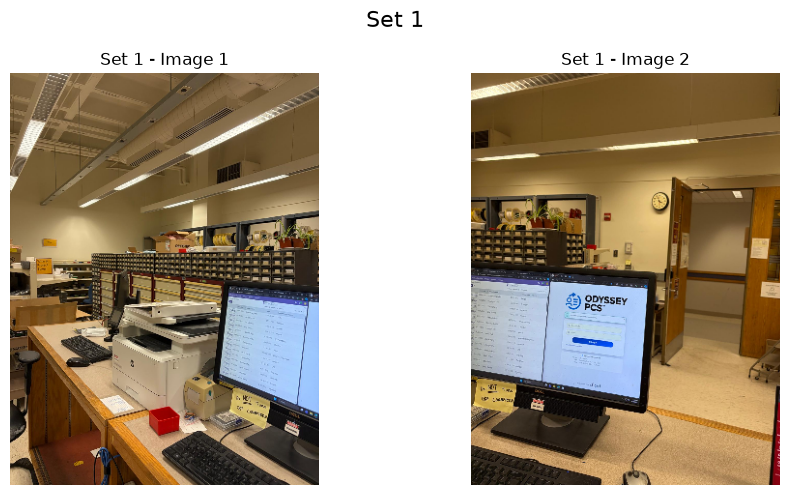

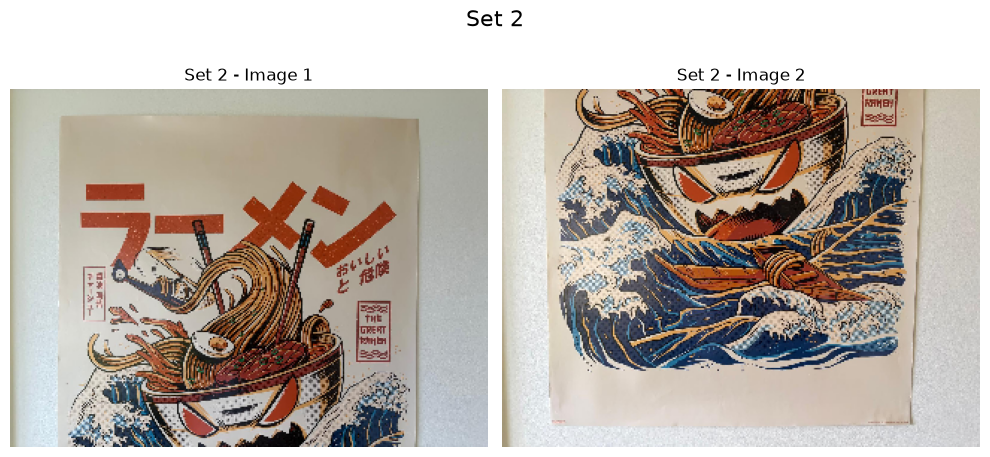

In [6]:
# Include both input sets as separate labeled thumbnail figures
import matplotlib.pyplot as plt


def make_thumbnail(image, width=320):
    height = int(image.shape[0] * width / image.shape[1])
    return cv2.resize(image, (width, height))


def display_set(title, images, labels):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(title, fontsize=16)

    for axis, image, label in zip(axes, images, labels):
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axis.set_title(label)
        axis.axis("off")

    fig.tight_layout()
    plt.show()


set1_thumbnails = [make_thumbnail(image_1), make_thumbnail(image_2)]
set2_thumbnails = [make_thumbnail(image_3), make_thumbnail(image_4)]

display_set(
    "Set 1",
    set1_thumbnails,
    ["Set 1 - Image 1", "Set 1 - Image 2"],
)
display_set(
    "Set 2",
    set2_thumbnails,
    ["Set 2 - Image 1", "Set 2 - Image 2"],
)


### PART 2: Descriptor Matching


In [7]:
# descriptor matching
def match_descriptors(descriptors1, descriptors2):
    if descriptors1 is None or descriptors2 is None or len(descriptors2) < 2:
        return []

    descriptors1 = np.asarray(descriptors1, dtype=np.float32)
    descriptors2 = np.asarray(descriptors2, dtype=np.float32)
    matches = []

    for query_index, descriptor in enumerate(descriptors1):
        distances = np.sum((descriptors2 - descriptor) ** 2, axis=1)
        nearest_indices = np.argsort(distances)[:2]
        first_index, second_index = nearest_indices
        matches.append((
            cv2.DMatch(
                query_index,
                int(first_index),
                0,
                float(np.sqrt(distances[first_index])),
            ),
            cv2.DMatch(
                query_index,
                int(second_index),
                0,
                float(np.sqrt(distances[second_index])),
            ),
        ))

    return matches

def ratio_test(matches, ratio_threshold=0.7):
    return [
        first_match
        for first_match, second_match in matches
        if first_match.distance < ratio_threshold * second_match.distance
    ]

In [8]:
# Draw matches

#Set1
nearest_matches = match_descriptors(descriptors1, descriptors2)
candidate_matches = [first_match for first_match, _ in nearest_matches]
matches1 = ratio_test(nearest_matches, ratio_threshold=0.7)

print("Candidate matches Set1:", len(candidate_matches))
print("Matches after ratio test Set1:", len(matches1))

matched_image_before = draw_matches(
    image_1, keypoints1, image_2, keypoints2, candidate_matches
)
matched_image = draw_matches(image_1, keypoints1, image_2, keypoints2, matches1)
save_image(matched_image_before, "outputs/Set1_matches_before_ratio.jpg")
save_image(matched_image, "outputs/Set1_matches_after_ratio.jpg")

#Set2
nearest_matches = match_descriptors(descriptors3, descriptors4)
candidate_matches = [first_match for first_match, _ in nearest_matches]
matches2 = ratio_test(nearest_matches) 

print("Candidate matches Set2:", len(candidate_matches))
print("Matches after ratio test Set2:", len(matches2))

matched_image_before = draw_matches(
    image_3, keypoints3, image_4, keypoints4, candidate_matches
)
matched_image = draw_matches(image_3, keypoints3, image_4, keypoints4, matches2)
save_image(matched_image_before, "outputs/Set2_matches_before_ratio.jpg")
save_image(matched_image, "outputs/Set2_matches_after_ratio.jpg")


Candidate matches Set1: 7460
Matches after ratio test Set1: 518
Candidate matches Set2: 9081
Matches after ratio test Set2: 2464


### PART 3: Homography Estimation


In [9]:
def project(H, pts):           # matrix multiply, then homogenous divide
    ph = np.column_stack([pts, np.ones(len(pts))]) @ H.T
    return ph[:, :2] / ph[:, 2:3]

def mean_err(H, src, dst):
    return np.linalg.norm(project(H, src) - dst, axis=1).mean()

def normalize_points(points):
    points = np.asarray(points, dtype=np.float64)
    center = points.mean(axis=0)
    distances = np.linalg.norm(points - center, axis=1)
    mean_distance = distances.mean()
    if mean_distance == 0:
        raise ValueError("Cannot normalize coincident points.")

    scale = np.sqrt(2.0) / mean_distance
    transform = np.array([
        [scale, 0.0, -scale * center[0]],
        [0.0, scale, -scale * center[1]],
        [0.0, 0.0, 1.0],
    ])
    homogeneous = np.column_stack([points, np.ones(len(points))])
    normalized = (transform @ homogeneous.T).T
    return normalized[:, :2], transform

def find_homography(src, dst):
    if len(src) != len(dst) or len(src) < 4:
        raise ValueError("Homography estimation requires at least four pairs.")

    normalized_src, src_transform = normalize_points(src)
    normalized_dst, dst_transform = normalize_points(dst)

    # Solve DLT in normalized coordinates for numerical stability.
    A = []
    for (x, y), (u, v) in zip(normalized_src, normalized_dst):
        A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])

    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    normalized_H = Vt[-1].reshape(3, 3)

    H = np.linalg.inv(dst_transform) @ normalized_H @ src_transform
    return H / H[2, 2]

H_true = np.array([[ 0.9,   0.1,  40.],
                [-0.05,  1.1,  20.],
                [ 3e-4, -2e-4,  1. ]]) # nonzero bottom row: real perspective

src = np.array([[50., 40.], [600., 70.], [560., 430.], [80., 400.]])
dst = project(H_true, src)          # (88.38, 61.07)  (503.43, 57.46) ...
H = find_homography(src, dst)       # your HW1 code (DLT) goes here 
print("Exact 4-point mean error:", f"{mean_err(H, src, dst):.2e}", "px")

rng = np.random.default_rng(0)
src = rng.uniform([0, 0], [640, 480], size=(20, 2))   # 20 points over the frame
dest = project(H_true, src)

H = find_homography(src, dest)
print("Exact 20-point mean error:", f"{mean_err(H, src, dest):.2e}", "px")

noisy = dest + rng.normal(0, 0.5, dest.shape)     # sigma = 0.5 px
H = find_homography(src, noisy)

print("Noisy fit error:", f"{mean_err(H, src, noisy):.2f}", "px")
print("Noisy fit error against clean points:", f"{mean_err(H, src, dest):.2f}", "px")


Exact 4-point mean error: 1.30e-13 px
Exact 20-point mean error: 1.17e-13 px
Noisy fit error: 0.62 px
Noisy fit error against clean points: 0.30 px


### PART 4: Basic Robust Estimation with RANSAC


In [10]:
def non_degenerate(points):
    a, b, c, d = points
    ab = b - a
    ac = c - a
    ad = d - a
    area_abc = ab[0] * ac[1] - ab[1] * ac[0]
    area_abd = ab[0] * ad[1] - ab[1] * ad[0]
    return abs(area_abc) > 1e-6 or abs(area_abd) > 1e-6

def ransac(src, dst, threshold=5.0, iterations=1000):
    rng = np.random.default_rng(0)
    best_H = None
    best_mask = None
    best_count = 0

    for _ in range(iterations):
        sample_indices = rng.choice(len(src), 4, replace=False)
        sample_src = src[sample_indices]
        sample_dst = dst[sample_indices]

        if not non_degenerate(sample_src) or not non_degenerate(sample_dst):
            continue

        candidate_H = find_homography(sample_src, sample_dst)
        errors = np.linalg.norm(project(candidate_H, src) - dst, axis=1)
        
        inlier_mask = errors < threshold
        inlier_count = int(inlier_mask.sum())

        if inlier_count > best_count:
            best_H = candidate_H
            best_count = inlier_count
            best_mask = inlier_mask

    return best_H, best_mask

In [11]:
# Set 1
src_points = np.float64([keypoints1[m.queryIdx].pt for m in matches1]) # type: ignore
dst_points = np.float64([keypoints2[m.trainIdx].pt for m in matches1]) # type: ignore

H_before_refit1, inlier_mask = ransac(src_points, dst_points)
H_after_refit1 = find_homography(src_points[inlier_mask], dst_points[inlier_mask])

before_error = np.linalg.norm(
    project(H_before_refit1, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()

after_error = np.linalg.norm(
    project(H_after_refit1, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()
print("SET 1")
print("Total matches:", len(matches1))
print("RANSAC inliers:", int(inlier_mask.sum()))
print("Inlier ratio:", f"{inlier_mask.mean():.2f}")
print("Mean inlier error before refit:", f"{before_error:.2f}", "px")
print("Mean inlier error after refit:", f"{after_error:.2f}", "px")

outlier_matches1 = [m for m, is_inlier in zip(matches1, inlier_mask) if not is_inlier]
inlier_matches1 = [m for m, is_inlier in zip(matches1, inlier_mask) if is_inlier]

ransac_image1 = cv2.drawMatches(
    image_1, keypoints1, image_2, keypoints2, tuple(outlier_matches1), None, # type: ignore
    (0, 0, 255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
) # type: ignore

for match in inlier_matches1:
    point1 = tuple(np.round(keypoints1[match.queryIdx].pt).astype(int))
    point2 = tuple(
        np.round(keypoints2[match.trainIdx].pt).astype(int)
        + np.array([image_1.shape[1], 0])
    )
    cv2.line(ransac_image1, point1, point2, (0, 255, 0), 1, cv2.LINE_AA)

save_image(ransac_image1, "outputs/Set1_ransac_matches.jpg")

# Set 2
src_points = np.float64([keypoints3[m.queryIdx].pt for m in matches2]) # type: ignore
dst_points = np.float64([keypoints4[m.trainIdx].pt for m in matches2]) # type: ignore

H_before_refit2, inlier_mask = ransac(src_points, dst_points)
H_after_refit2 = find_homography(src_points[inlier_mask], dst_points[inlier_mask])

before_error = np.linalg.norm(
    project(H_before_refit2, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()

after_error = np.linalg.norm(
    project(H_after_refit2, src_points[inlier_mask])
    - dst_points[inlier_mask], axis=1
).mean()

print()
print("SET 2")
print("Total matches:", len(matches2))
print("RANSAC inliers:", int(inlier_mask.sum()))
print("Inlier ratio:", f"{inlier_mask.mean():.2f}")
print("Mean inlier error before refit:", f"{before_error:.2f}", "px")
print("Mean inlier error after refit:", f"{after_error:.2f}", "px")

outlier_matches2 = [m for m, is_inlier in zip(matches2, inlier_mask) if not is_inlier]
inlier_matches2 = [m for m, is_inlier in zip(matches2, inlier_mask) if is_inlier]

ransac_image2 = cv2.drawMatches(
    image_3, keypoints3, image_4, keypoints4, tuple(outlier_matches2), None, # type: ignore
    (0, 0, 255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
) # type: ignore

for match in inlier_matches2:
    point1 = tuple(np.round(keypoints3[match.queryIdx].pt).astype(int))
    point2 = tuple(
        np.round(keypoints4[match.trainIdx].pt).astype(int)
        + np.array([image_3.shape[1], 0])
    )
    cv2.line(ransac_image2, point1, point2, (0, 255, 0), 1, cv2.LINE_AA)

save_image(ransac_image2, "outputs/Set2_ransac_matches.jpg")


/tmp/ipykernel_47453/2440212115.py:3: RuntimeWarning: divide by zero encountered in divide
  return ph[:, :2] / ph[:, 2:3]
/tmp/ipykernel_47453/2440212115.py:3: RuntimeWarning: invalid value encountered in divide
  return ph[:, :2] / ph[:, 2:3]


SET 1
Total matches: 518
RANSAC inliers: 187
Inlier ratio: 0.36
Mean inlier error before refit: 1.48 px
Mean inlier error after refit: 0.87 px

SET 2
Total matches: 2464
RANSAC inliers: 2316
Inlier ratio: 0.94
Mean inlier error before refit: 1.72 px
Mean inlier error after refit: 1.07 px


### PART 5: Warping and Compositing


In [12]:
def warp_image(image, image_to_canvas, canvas_shape):
    canvas_height, canvas_width = canvas_shape
    rows, cols = np.indices((canvas_height, canvas_width), dtype=np.float64)

    canvas_points = np.column_stack([cols.ravel(), rows.ravel(), np.ones(rows.size)])

    source = (np.linalg.inv(image_to_canvas) @ canvas_points.T).T
    source = source[:, :2] / source[:, 2:3]
    source_x = source[:, 0].reshape(canvas_shape).astype(np.float32)
    source_y = source[:, 1].reshape(canvas_shape).astype(np.float32)

    valid = (
        np.isfinite(source_x)
        & np.isfinite(source_y)
        & (source_x >= 0)
        & (source_x <= image.shape[1] - 1)
        & (source_y >= 0)
        & (source_y <= image.shape[0] - 1)
    )

    warped = cv2.remap(
        image,
        source_x,
        source_y,
        cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
    )

    return warped, valid

def transform_corners(corners, image_to_canvas):
    homogeneous = np.column_stack([corners, np.ones(len(corners))])
    transformed = (image_to_canvas @ homogeneous.T).T
    return transformed[:, :2] / transformed[:, 2:3]

In [13]:
# SYNTHETIC TEST

# Synthetic warp checks with identifiable landmarks.
test_image = np.zeros((80, 100, 3), dtype=np.uint8)
landmarks = np.array([[20, 20], [70, 25], [35, 60]], dtype=np.float64)

for x, y in landmarks.astype(int):
    cv2.rectangle(test_image, (x - 2, y - 2), (x + 2, y + 2), (255, 255, 255), -1)

def check_warp(name, transform, offset):
    image_to_canvas = offset @ transform
    warped, valid = warp_image(test_image, image_to_canvas, (140, 180))
    expected = project(image_to_canvas, landmarks)

    for x, y in np.round(expected).astype(int):
        patch = warped[max(0, y - 2):y + 3, max(0, x - 2):x + 3]

        if not valid[y, x] or patch.max() < 200:
            raise AssertionError(f"{name} landmark check failed at {(x, y)}")
        
    save_image(warped, f"outputs/synthetic_warp_{name}.png")

    print(f"Synthetic {name} transform:\n", transform)
    print(f"Synthetic {name} landmarks verified at:", expected.astype(int).tolist())

test_offset = np.array([
    [1.0, 0.0, 30.0],
    [0.0, 1.0, 25.0],
    [0.0, 0.0, 1.0],
])

check_warp(
    "translation",
    np.array([[1.0, 0.0, -20.0], [0.0, 1.0, -15.0], [0.0, 0.0, 1.0]]),
    test_offset,
)
check_warp(
    "scale",
    np.array([[1.4, 0.0, 0.0], [0.0, 1.4, 0.0], [0.0, 0.0, 1.0]]),
    test_offset,
)

save_image(test_image, "outputs/synthetic_warp_input.png")

Synthetic translation transform:
 [[  1.   0. -20.]
 [  0.   1. -15.]
 [  0.   0.   1.]]
Synthetic translation landmarks verified at: [[30, 30], [80, 35], [45, 70]]
Synthetic scale transform:
 [[1.4 0.  0. ]
 [0.  1.4 0. ]
 [0.  0.  1. ]]
Synthetic scale landmarks verified at: [[58, 53], [128, 60], [79, 109]]


In [14]:
# SET 1 PANORAMA
image_2_to_image_1 = np.linalg.inv(H_after_refit1)

corners_1 = np.array([
    [0, 0],
    [image_1.shape[1] - 1, 0],
    [image_1.shape[1] - 1, image_1.shape[0] - 1],
    [0, image_1.shape[0] - 1],
], dtype=np.float64)

corners_2 = np.array([
    [0, 0],
    [image_2.shape[1] - 1, 0],
    [image_2.shape[1] - 1, image_2.shape[0] - 1],
    [0, image_2.shape[0] - 1],
], dtype=np.float64)

transformed_corners1 = np.vstack([
    corners_1,
    project(image_2_to_image_1, corners_2),
])

minimum1 = np.floor(transformed_corners1.min(axis=0)).astype(int)
maximum1 = np.ceil(transformed_corners1.max(axis=0)).astype(int)

offset1 = np.array([
    [1.0, 0.0, -minimum1[0]],
    [0.0, 1.0, -minimum1[1]],
    [0.0, 0.0, 1.0],
])

canvas_shape1 = (
    int(maximum1[1] - minimum1[1] + 1),
    int(maximum1[0] - minimum1[0] + 1),
)

warped_1, valid_1 = warp_image(image_1, offset1, canvas_shape1)
warped_2, valid_2 = warp_image(image_2, offset1 @ image_2_to_image_1, canvas_shape1)

panorama1 = np.zeros_like(warped_1)
panorama1[valid_1] = warped_1[valid_1]
panorama1[valid_2] = warped_2[valid_2]

save_image(panorama1, "outputs/Set1_panorama.jpg")
print("Panorama 1 canvas:", canvas_shape1[1], "x", canvas_shape1[0])

boundary_image1 = panorama1.copy()
boundary_1 = np.round(transform_corners(corners_1, offset1)).astype(np.int32)
boundary_2 = np.round(
    transform_corners(corners_2, offset1 @ image_2_to_image_1)
).astype(np.int32)

cv2.polylines(boundary_image1, [boundary_1], True, (255, 0, 0), 6)
cv2.polylines(boundary_image1, [boundary_2], True, (0, 255, 255), 6)

save_image(boundary_image1, "outputs/Set1_panorama_annotated.jpg")

Panorama 1 canvas: 3139 x 3064


In [15]:
# SET 2 PANORAMA
image_4_to_image_3 = np.linalg.inv(H_after_refit2)

corners_3 = np.array([
    [0, 0],
    [image_3.shape[1] - 1, 0],
    [image_3.shape[1] - 1, image_3.shape[0] - 1],
    [0, image_3.shape[0] - 1],
], dtype=np.float64)    

corners_4 = np.array([
    [0, 0],
    [image_4.shape[1] - 1, 0],
    [image_4.shape[1] - 1, image_4.shape[0] - 1],
    [0, image_4.shape[0] - 1],
], dtype=np.float64)

transformed_corners2 = np.vstack([
    corners_3,
    project(image_4_to_image_3, corners_4),
])

minimum2 = np.floor(transformed_corners2.min(axis=0)).astype(int)
maximum2 = np.ceil(transformed_corners2.max(axis=0)).astype(int)

offset2 = np.array([
    [1.0, 0.0, -minimum2[0]],
    [0.0, 1.0, -minimum2[1]],
    [0.0, 0.0, 1.0],
])

canvas_shape2 = (
    int(maximum2[1] - minimum2[1] + 1),
    int(maximum2[0] - minimum2[0] + 1),
)

warped_3, valid_3 = warp_image(image_3, offset2, canvas_shape2)
warped_4, valid_4 = warp_image(image_4, offset2 @ image_4_to_image_3, canvas_shape2)

panorama2 = np.zeros_like(warped_3)
panorama2[valid_3] = warped_3[valid_3]
panorama2[valid_4] = warped_4[valid_4]

save_image(panorama2, "outputs/Set2_panorama.jpg")
print("Panorama 2 canvas:", canvas_shape2[1], "x", canvas_shape2[0])

boundary_image2 = panorama2.copy()
boundary_3 = np.round(transform_corners(corners_3, offset2)).astype(np.int32)
boundary_4 = np.round(
    transform_corners(corners_4, offset2 @ image_4_to_image_3)
).astype(np.int32)

cv2.polylines(boundary_image2, [boundary_3], True, (255, 0, 0), 6)
cv2.polylines(boundary_image2, [boundary_4], True, (0, 255, 255), 6)

save_image(boundary_image2, "outputs/Set2_panorama_annotated.jpg")

Panorama 2 canvas: 1605 x 1981


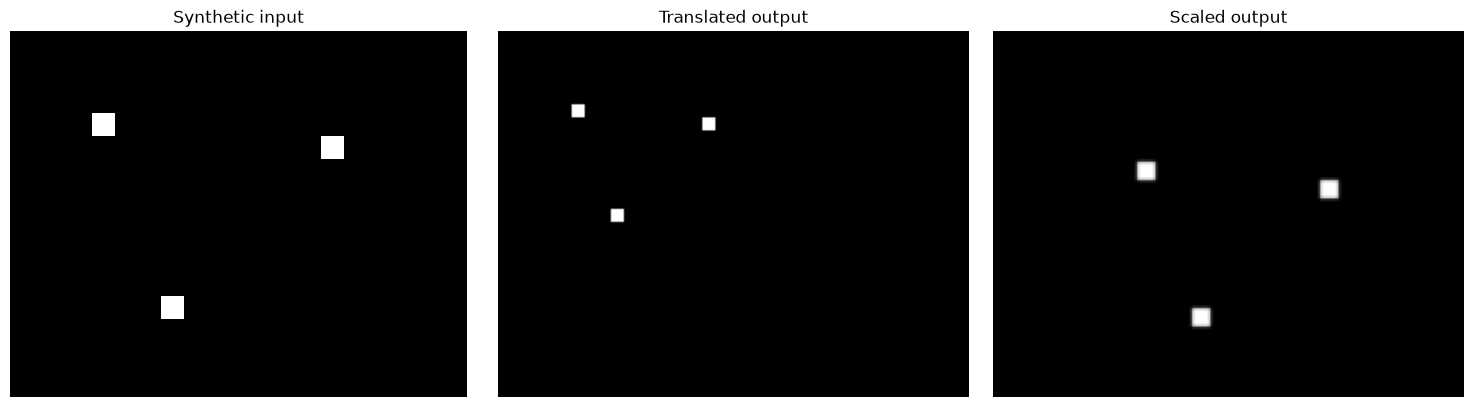

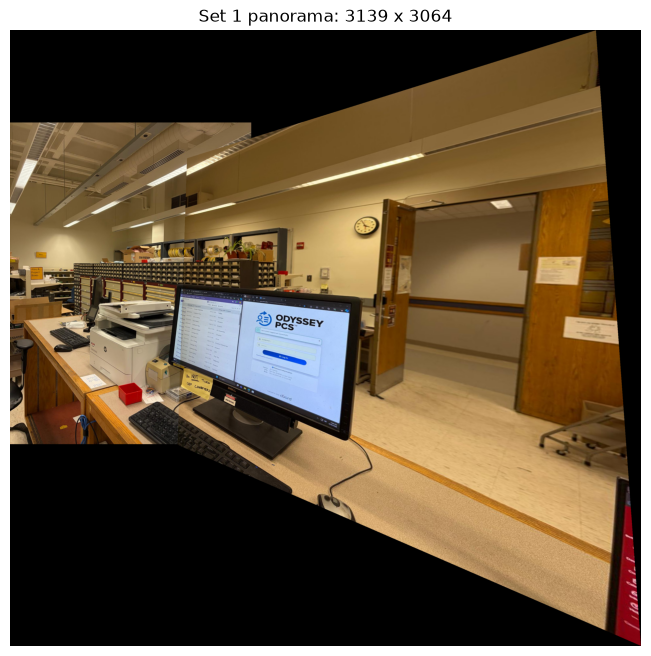

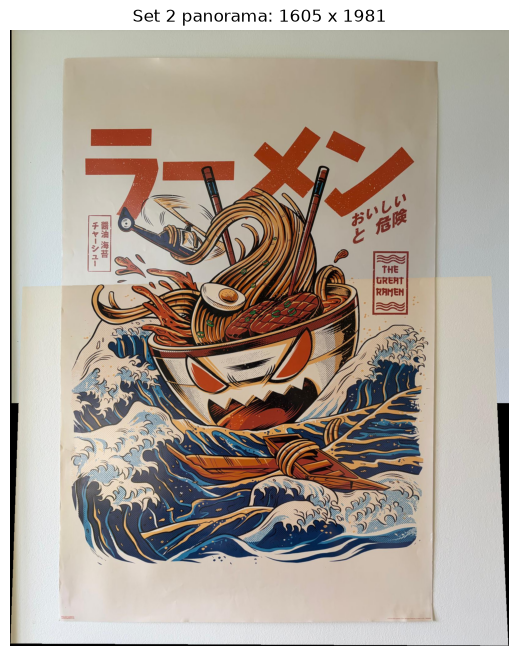

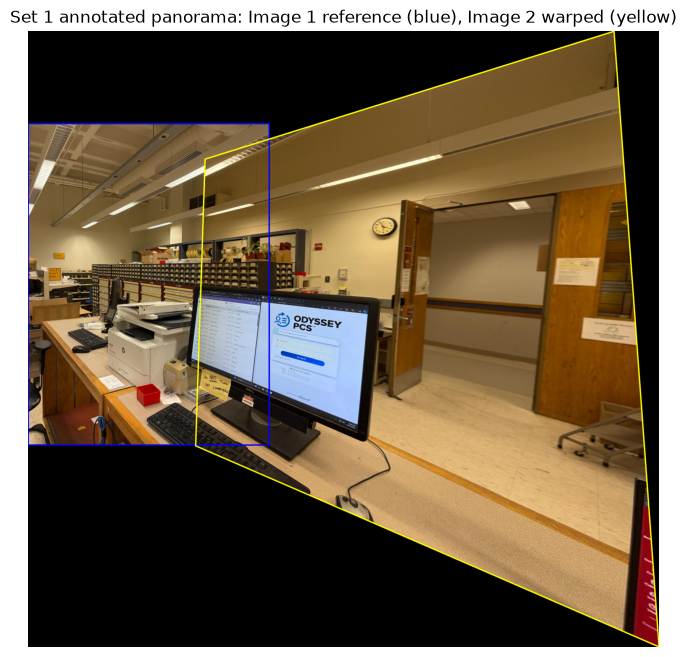

In [16]:
import matplotlib.pyplot as plt

warped_translation = load_image("outputs/synthetic_warp_translation.png")
warped_scale = load_image("outputs/synthetic_warp_scale.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, image, title in zip(
    axes,
    [test_image, warped_translation, warped_scale],
    ["Synthetic input", "Translated output", "Scaled output"],
):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")
fig.tight_layout()
plt.show()

for image, title in [
    (panorama1, "Set 1 panorama: 3139 x 3064"),
    (panorama2, "Set 2 panorama: 1605 x 1981"),
]:
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(boundary_image1, cv2.COLOR_BGR2RGB))
plt.title("Set 1 annotated panorama: Image 1 reference (blue), Image 2 warped (yellow)")
plt.axis("off")
plt.show()


### Part 6: Feather Blending


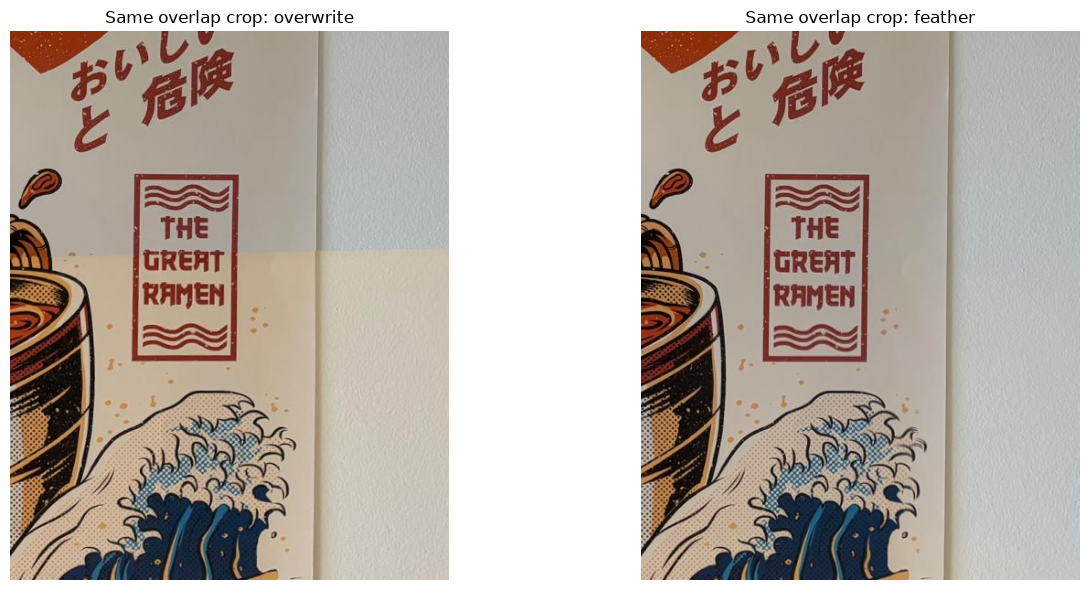

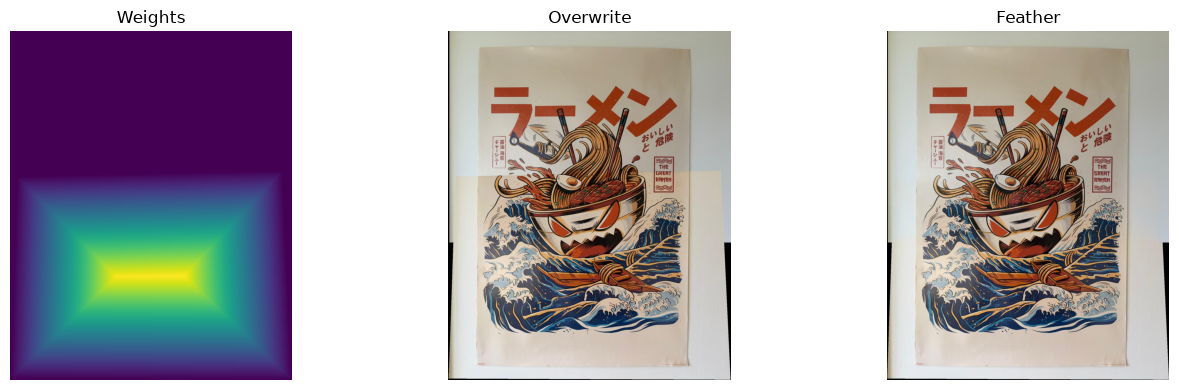

In [17]:
# SET 2 FEATHER BLENDING
warped_images = [warped_3, warped_4]
valid_masks = [valid_3, valid_4]
canvas_h, canvas_w = canvas_shape2

# Baseline overwrite compositing: image 4 replaces image 3 in the overlap.
overwrite = np.zeros_like(warped_3)
overwrite[valid_masks[0]] = warped_images[0][valid_masks[0]]
overwrite[valid_masks[1]] = warped_images[1][valid_masks[1]]

# Distance-to-boundary weights fade each image toward its valid-mask edge.
weights = []
for valid in valid_masks:
    padded_mask = np.pad(valid.astype(np.uint8), 1, constant_values=0)
    distance = cv2.distanceTransform(padded_mask, cv2.DIST_L2, 5)[1:-1, 1:-1]
    weights.append(np.maximum(distance, 1e-3) * valid)

numerator = np.zeros_like(warped_3, dtype=np.float32)
denominator = np.zeros((canvas_h, canvas_w), dtype=np.float32)
for warped, weight in zip(warped_images, weights):
    numerator += warped.astype(np.float32) * weight[..., None]
    denominator += weight

feathered = np.divide(
    numerator,
    np.maximum(denominator, 1e-6)[..., None],
).astype(np.uint8)

# Use one crop from the actual overlap to compare the same seam.
overlap = valid_masks[0] & valid_masks[1]
overlap_rows, overlap_cols = np.where(overlap)
center_row = int(np.median(overlap_rows))
center_col = int(np.median(overlap_cols))
row_start = max(0, center_row - 450)
row_end = min(canvas_h, center_row + 150)
col_start = max(0, center_col + 220)
col_end = min(canvas_w, center_col + 700)
region = np.s_[row_start:row_end, col_start:col_end]

def show_bgr(image, title, region=None):
    view = image if region is None else image[region]
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(view, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# show_bgr(overwrite, "Set 2 overwrite panorama")
# show_bgr(feathered, "Set 2 feather-blended panorama")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, result, title in zip(
    axes,
    [overwrite, feathered],
    ["Same overlap crop: overwrite", "Same overlap crop: feather"],
):
    ax.imshow(cv2.cvtColor(result[region], cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(weights[1], cmap="viridis")
axes[0].set_title("Weights")
axes[1].imshow(cv2.cvtColor(overwrite, cv2.COLOR_BGR2RGB))
axes[1].set_title("Overwrite")
axes[2].imshow(cv2.cvtColor(feathered, cv2.COLOR_BGR2RGB))
axes[2].set_title("Feather")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


### Part 7: Confidence-Based RANSAC Stopping

The adaptive RANSAC target confidence is $p=0.99$. After each improved model, with inlier fraction $w$ and four-point samples, the required iteration count is

$$N = \left\lceil \frac{\log(1-p)}{\log(1-w^4)} \right\rceil.$$

The loop stops when the current iteration reaches this updated requirement, capped at the original 1,000-iteration budget.


In [18]:
def confidence_ransac(
    src,
    dst,
    threshold=5.0,
    confidence=0.99,
    sample_size=4,
    max_iterations=1000,
):
    rng = np.random.default_rng(0)
    best_H = None
    best_mask = None
    best_count = 0
    required_iterations = max_iterations
    iteration = 0

    while iteration < min(required_iterations, max_iterations):
        iteration += 1
        sample_indices = rng.choice(len(src), sample_size, replace=False)
        sample_src = src[sample_indices]
        sample_dst = dst[sample_indices]

        if not non_degenerate(sample_src) or not non_degenerate(sample_dst):
            continue

        candidate_H = find_homography(sample_src, sample_dst)
        errors = np.linalg.norm(project(candidate_H, src) - dst, axis=1)
        inlier_mask = errors < threshold
        inlier_count = int(inlier_mask.sum())

        if inlier_count > best_count:
            best_H = candidate_H
            best_mask = inlier_mask
            best_count = inlier_count
            inlier_fraction = best_count / len(src)
            success_probability = inlier_fraction ** sample_size

            if success_probability >= 1.0:
                required_iterations = 1
            elif success_probability > 0.0:
                required_iterations = int(
                    np.ceil(
                        np.log(1.0 - confidence)
                        / np.log(1.0 - success_probability)
                    )
                )
                required_iterations = max(1, required_iterations)

            required_iterations = min(required_iterations, max_iterations)

    return best_H, best_mask, iteration, required_iterations


def run_confidence_ransac(src_points, dst_points, name, fixed_inliers):
    _, adaptive_mask, iterations_used, required_iterations = confidence_ransac(
        src_points, dst_points
    )
    adaptive_inliers = int(adaptive_mask.sum())
    print(name)
    print("Fixed budget: 1000 iterations; inliers:", fixed_inliers)
    print("Adaptive iterations used:", iterations_used)
    print("Adaptive required iterations at stop:", required_iterations)
    print("Adaptive final inliers:", adaptive_inliers)
    print()


set1_src_points = np.float64([keypoints1[m.queryIdx].pt for m in matches1])
set1_dst_points = np.float64([keypoints2[m.trainIdx].pt for m in matches1])
set2_src_points = np.float64([keypoints3[m.queryIdx].pt for m in matches2])
set2_dst_points = np.float64([keypoints4[m.trainIdx].pt for m in matches2])

run_confidence_ransac(set1_src_points, set1_dst_points, "SET 1", 187)
run_confidence_ransac(set2_src_points, set2_dst_points, "SET 2", 2316)


SET 1
Fixed budget: 1000 iterations; inliers: 187
Adaptive iterations used: 287
Adaptive required iterations at stop: 287
Adaptive final inliers: 184

SET 2
Fixed budget: 1000 iterations; inliers: 2316
Adaptive iterations used: 16
Adaptive required iterations at stop: 16
Adaptive final inliers: 1743



/tmp/ipykernel_47453/2440212115.py:3: RuntimeWarning: divide by zero encountered in divide
  return ph[:, :2] / ph[:, 2:3]
/tmp/ipykernel_47453/2440212115.py:3: RuntimeWarning: invalid value encountered in divide
  return ph[:, :2] / ph[:, 2:3]


### Part 8: Exposure and Gain Compensation


/tmp/ipykernel_47453/2440212115.py:3: RuntimeWarning: divide by zero encountered in divide
  return ph[:, :2] / ph[:, 2:3]
/tmp/ipykernel_47453/2440212115.py:3: RuntimeWarning: invalid value encountered in divide
  return ph[:, :2] / ph[:, 2:3]


Estimated gains: {'Image 1 (reference)': 1.0, 'Image 2': 0.44621047377586365}
Exposure-pair inliers: 42
Exposure panorama canvas: 2547 x 2641


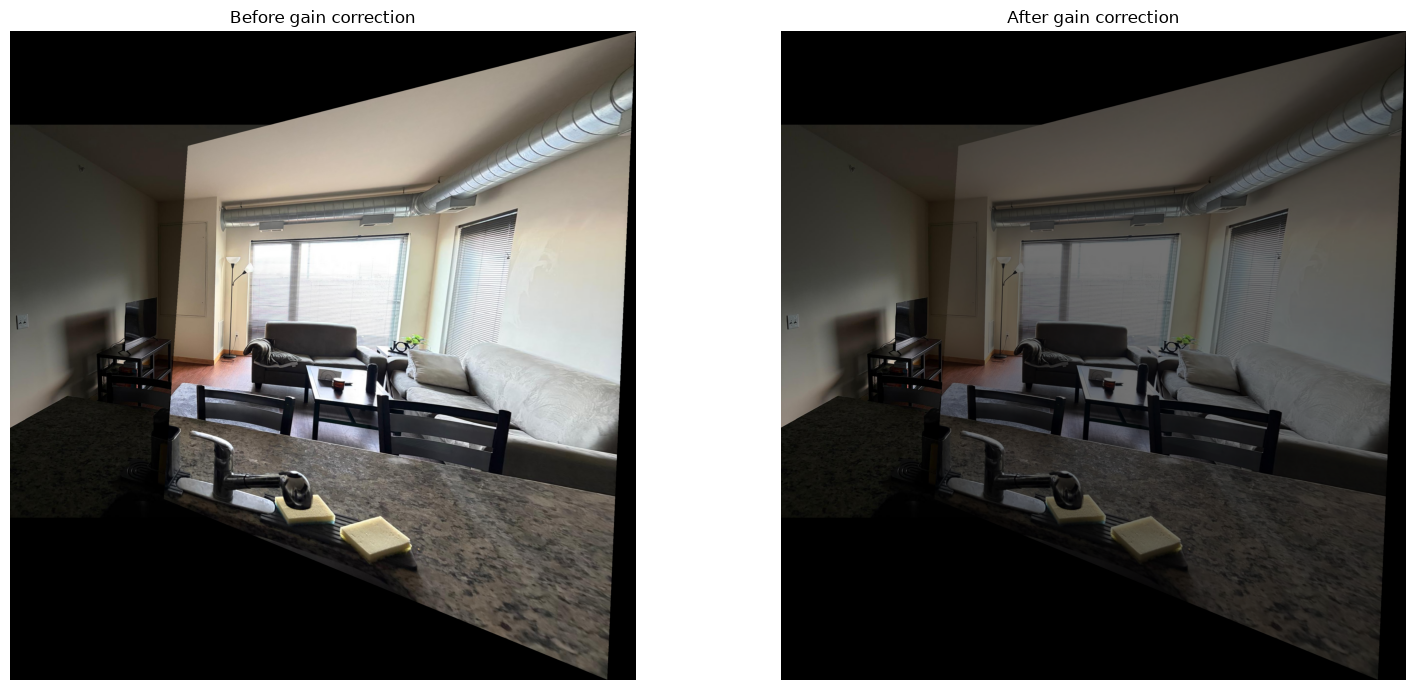

In [19]:
# Exposure and gain compensation for a separate exposure-mismatched pair.
from pathlib import Path

exposure_paths = [
    Path("Images/exposure_1.jpeg"),
    Path("Images/exposure_2.jpeg"),
]

if not all(path.exists() for path in exposure_paths):
    missing = [str(path) for path in exposure_paths if not path.exists()]
    print("Save the attached exposure pair as:", ", ".join(str(path) for path in exposure_paths))
    print("Missing:", ", ".join(missing))
else:
    exposure_1 = load_image(str(exposure_paths[0]))
    exposure_2 = load_image(str(exposure_paths[1]))

    exposure_keypoints1, exposure_descriptors1 = detect_and_compute_sift(exposure_1)
    exposure_keypoints2, exposure_descriptors2 = detect_and_compute_sift(exposure_2)
    exposure_matches = ratio_test(
        match_descriptors(exposure_descriptors1, exposure_descriptors2)
    )

    exposure_src = np.float64([
        exposure_keypoints1[match.queryIdx].pt for match in exposure_matches
    ])
    exposure_dst = np.float64([
        exposure_keypoints2[match.trainIdx].pt for match in exposure_matches
    ])
    exposure_H, exposure_inliers = ransac(exposure_src, exposure_dst)
    exposure_H = find_homography(
        exposure_src[exposure_inliers], exposure_dst[exposure_inliers]
    )
    exposure_2_to_1 = np.linalg.inv(exposure_H)

    exposure_corners1 = np.array([
        [0, 0],
        [exposure_1.shape[1] - 1, 0],
        [exposure_1.shape[1] - 1, exposure_1.shape[0] - 1],
        [0, exposure_1.shape[0] - 1],
    ], dtype=np.float64)
    exposure_corners2 = np.array([
        [0, 0],
        [exposure_2.shape[1] - 1, 0],
        [exposure_2.shape[1] - 1, exposure_2.shape[0] - 1],
        [0, exposure_2.shape[0] - 1],
    ], dtype=np.float64)
    exposure_transformed_corners = np.vstack([
        exposure_corners1,
        project(exposure_2_to_1, exposure_corners2),
    ])
    exposure_minimum = np.floor(exposure_transformed_corners.min(axis=0)).astype(int)
    exposure_maximum = np.ceil(exposure_transformed_corners.max(axis=0)).astype(int)
    exposure_offset = np.array([
        [1.0, 0.0, -exposure_minimum[0]],
        [0.0, 1.0, -exposure_minimum[1]],
        [0.0, 0.0, 1.0],
    ])
    exposure_canvas_shape = (
        int(exposure_maximum[1] - exposure_minimum[1] + 1),
        int(exposure_maximum[0] - exposure_minimum[0] + 1),
    )

    exposure_warped1, exposure_valid1 = warp_image(
        exposure_1, exposure_offset, exposure_canvas_shape
    )
    exposure_warped2, exposure_valid2 = warp_image(
        exposure_2,
        exposure_offset @ exposure_2_to_1,
        exposure_canvas_shape,
    )

    exposure_gray1 = cv2.cvtColor(exposure_warped1, cv2.COLOR_BGR2GRAY).astype(np.float32)
    exposure_gray2 = cv2.cvtColor(exposure_warped2, cv2.COLOR_BGR2GRAY).astype(np.float32)
    exposure_overlap = (
        exposure_valid1
        & exposure_valid2
        & (exposure_gray1 > 5)
        & (exposure_gray2 > 5)
    )

    # Use image 1 as the reference: I2_corrected = gain2 * I2.
    gain1 = 1.0
    gain2 = float(
        np.sum(exposure_gray1[exposure_overlap] * exposure_gray2[exposure_overlap])
        / np.sum(exposure_gray2[exposure_overlap] ** 2)
    )
    gain2 = float(np.clip(gain2, 0.2, 5.0))
    exposure_corrected2 = np.clip(
        exposure_warped2.astype(np.float32) * gain2, 0, 255
    ).astype(np.uint8)

    panorama_before_gain = np.zeros_like(exposure_warped1)
    panorama_before_gain[exposure_valid1] = exposure_warped1[exposure_valid1]
    panorama_before_gain[exposure_valid2] = exposure_warped2[exposure_valid2]

    panorama_after_gain = np.zeros_like(exposure_warped1)
    panorama_after_gain[exposure_valid1] = exposure_warped1[exposure_valid1]
    panorama_after_gain[exposure_valid2] = exposure_corrected2[exposure_valid2]

    save_image(panorama_before_gain, "outputs/exposure_panorama_before_gain.jpg")
    save_image(panorama_after_gain, "outputs/exposure_panorama_after_gain.jpg")

    print("Estimated gains:", {"Image 1 (reference)": gain1, "Image 2": gain2})
    print("Exposure-pair inliers:", int(exposure_inliers.sum()))
    print("Exposure panorama canvas:", exposure_canvas_shape[1], "x", exposure_canvas_shape[0])

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for axis, image, title in zip(
        axes,
        [panorama_before_gain, panorama_after_gain],
        ["Before gain correction", "After gain correction"],
    ):
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()
    plt.show()


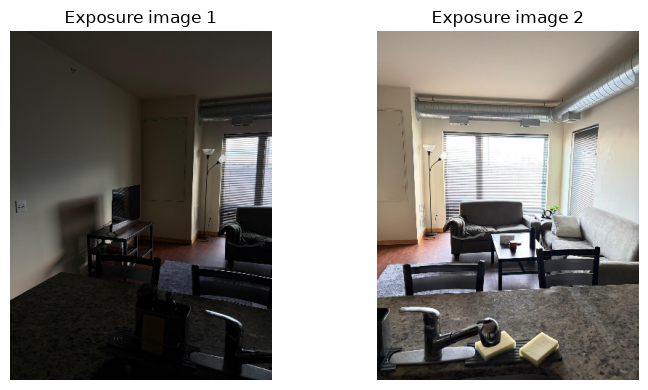

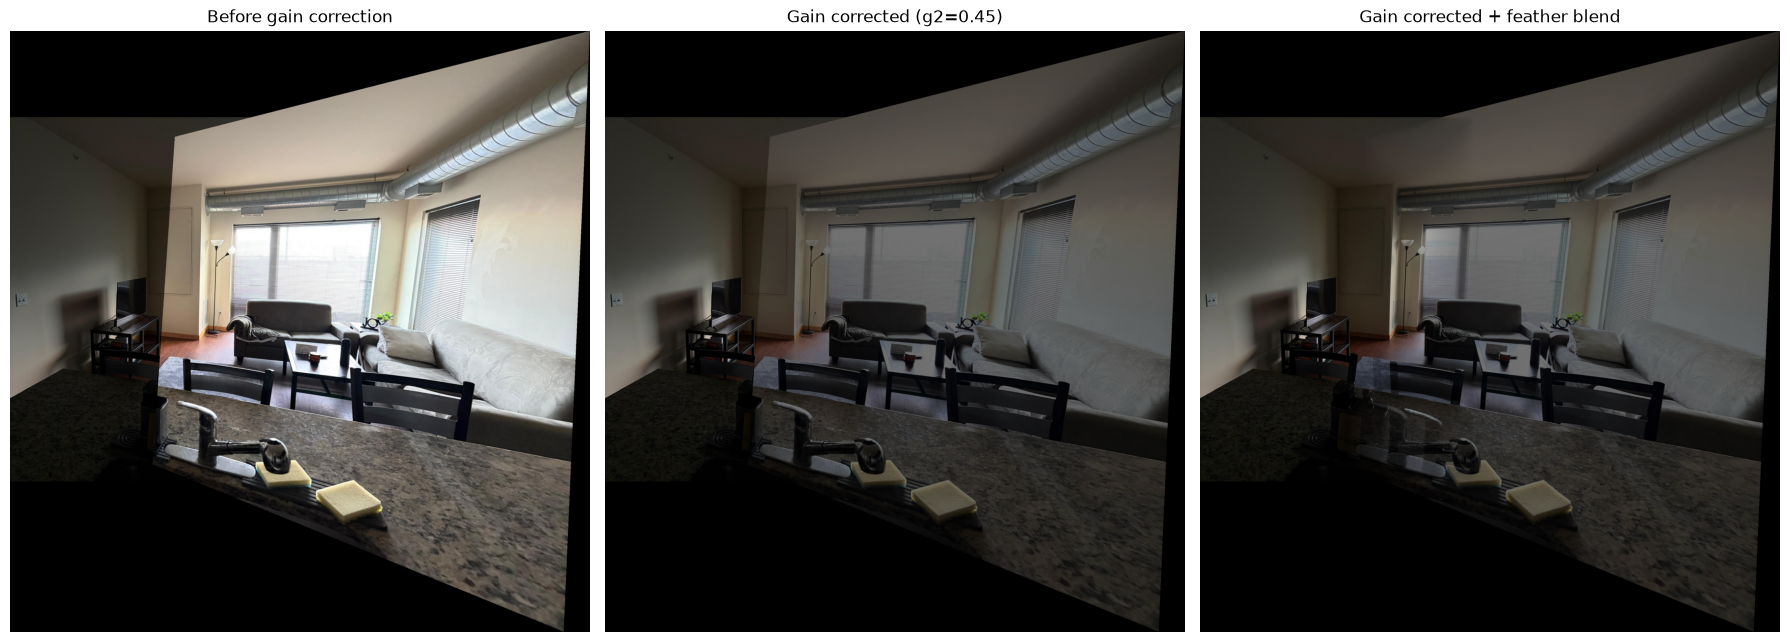

In [20]:
# Thumbnail inputs and compare overwrite, gain correction, and gain-plus-feather blending.
if "exposure_1" not in globals():
    print("Run the exposure cell after adding Images/exposure_1.jpeg and Images/exposure_2.jpeg.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for axis, image, title in zip(
        axes,
        [exposure_1, exposure_2],
        ["Exposure image 1", "Exposure image 2"],
    ):
        thumbnail_width = 360
        thumbnail_height = int(image.shape[0] * thumbnail_width / image.shape[1])
        thumbnail = cv2.resize(image, (thumbnail_width, thumbnail_height))
        axis.imshow(cv2.cvtColor(thumbnail, cv2.COLOR_BGR2RGB))
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()
    plt.show()

    exposure_weights = []
    for valid in [exposure_valid1, exposure_valid2]:
        padded_mask = np.pad(valid.astype(np.uint8), 1, constant_values=0)
        distance = cv2.distanceTransform(padded_mask, cv2.DIST_L2, 5)[1:-1, 1:-1]
        exposure_weights.append(np.maximum(distance, 1e-3) * valid)

    feather_numerator = np.zeros_like(exposure_warped1, dtype=np.float32)
    feather_denominator = np.zeros(exposure_canvas_shape, dtype=np.float32)
    for warped, weight in zip(
        [exposure_warped1, exposure_corrected2], exposure_weights
    ):
        feather_numerator += warped.astype(np.float32) * weight[..., None]
        feather_denominator += weight

    panorama_gain_feathered = np.divide(
        feather_numerator,
        np.maximum(feather_denominator, 1e-6)[..., None],
    ).astype(np.uint8)
    save_image(
        panorama_gain_feathered,
        "outputs/exposure_panorama_gain_feathered.jpg",
    )

    comparisons = [
        panorama_before_gain,
        panorama_after_gain,
        panorama_gain_feathered,
    ]
    titles = [
        "Before gain correction",
        f"Gain corrected (g2={gain2:.2f})",
        "Gain corrected + feather blend",
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    for axis, image, title in zip(axes, comparisons, titles):
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()
    plt.show()


### Part 9: Cylindrical Panorama


In [39]:
cylindrical_paths = [
    "Images/cylindrical_1.jpeg",
    "Images/cylindrical_2.jpeg",
    "Images/cylindrical_3.jpeg",
]
cylindrical_images = [load_image(path) for path in cylindrical_paths]
focal_scale = 700.0


def cylindrical_map(image, focal_length):
    height, width = image.shape[:2]
    center_x = (width - 1) / 2.0
    center_y = (height - 1) / 2.0
    columns, rows = np.meshgrid(
        np.arange(width, dtype=np.float32),
        np.arange(height, dtype=np.float32),
    )
    theta = (columns - center_x) / focal_length
    source_x = focal_length * np.tan(theta) + center_x
    source_y = (rows - center_y) / np.cos(theta) + center_y
    valid = (
        (source_x >= 0)
        & (source_x <= width - 1)
        & (source_y >= 0)
        & (source_y <= height - 1)
    )
    projected = cv2.remap(
        image,
        source_x.astype(np.float32),
        source_y.astype(np.float32),
        cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
    )
    valid_columns = np.where(valid.any(axis=0))[0]
    left, right = valid_columns[0], valid_columns[-1] + 1
    return projected[:, left:right], valid[:, left:right]


# Flat panorama correction: use Image 2 as the reference image.
def stitch_flat_with_reference(images, reference_index=1):
    reference = images[reference_index]
    reference_keypoints, reference_descriptors = detect_and_compute_sift(reference)
    transforms = [None] * len(images)
    transforms[reference_index] = np.eye(3)

    for index, image in enumerate(images):
        if index == reference_index:
            continue
        keypoints, descriptors = detect_and_compute_sift(image)
        matches = ratio_test(match_descriptors(descriptors, reference_descriptors))
        source_points = np.float64([keypoints[m.queryIdx].pt for m in matches])
        target_points = np.float64([
            reference_keypoints[m.trainIdx].pt for m in matches
        ])
        _, inliers = ransac(source_points, target_points)
        transforms[index] = find_homography(
            source_points[inliers], target_points[inliers]
        )

    transformed_corners = []
    for image, transform in zip(images, transforms):
        corners = np.array([
            [0, 0],
            [image.shape[1] - 1, 0],
            [image.shape[1] - 1, image.shape[0] - 1],
            [0, image.shape[0] - 1],
        ], dtype=np.float64)
        transformed_corners.append(project(transform, corners))

    all_corners = np.vstack(transformed_corners)
    minimum = np.floor(all_corners.min(axis=0)).astype(int)
    maximum = np.ceil(all_corners.max(axis=0)).astype(int)
    offset = np.array([
        [1.0, 0.0, -minimum[0]],
        [0.0, 1.0, -minimum[1]],
        [0.0, 0.0, 1.0],
    ])
    canvas_shape = (
        int(maximum[1] - minimum[1] + 1),
        int(maximum[0] - minimum[0] + 1),
    )

    panorama = np.zeros((*canvas_shape, 3), dtype=np.uint8)
    for image, transform in zip(images, transforms):
        warped, valid = warp_image(image, offset @ transform, canvas_shape)
        panorama[valid] = warped[valid]
    return panorama


def stitch_cylindrical_images(images, focal_length):
    projected = [cylindrical_map(image, focal_length) for image in images]
    projected_images = [item[0] for item in projected]
    projected_masks = [item[1] for item in projected]
    positions = [np.array([0, 0], dtype=int)]

    for previous, current in zip(projected_images, projected_images[1:]):
        previous_keypoints, previous_descriptors = detect_and_compute_sift(previous)
        current_keypoints, current_descriptors = detect_and_compute_sift(current)
        matches = ratio_test(
            match_descriptors(previous_descriptors, current_descriptors)
        )
        shifts = np.float64([
            np.array(previous_keypoints[m.queryIdx].pt)
            - np.array(current_keypoints[m.trainIdx].pt)
            for m in matches
        ])
        shift = np.median(shifts, axis=0)
        positions.append(positions[-1] + np.round(shift).astype(int))

    corners = [
        np.array([[0, 0], [image.shape[1] - 1, image.shape[0] - 1]])
        + position
        for image, position in zip(projected_images, positions)
    ]
    minimum = np.min(np.vstack(corners), axis=0)
    maximum = np.max(np.vstack(corners), axis=0)
    canvas_shape = (
        int(maximum[1] - minimum[1] + 1),
        int(maximum[0] - minimum[0] + 1),
    )
    offset = -minimum

    numerator = np.zeros((*canvas_shape, 3), dtype=np.float32)
    denominator = np.zeros(canvas_shape, dtype=np.float32)
    for image, valid, position in zip(projected_images, projected_masks, positions):
        x0, y0 = (position + offset).astype(int)
        height, width = image.shape[:2]
        padded_mask = np.pad(valid.astype(np.uint8), 1, constant_values=0)
        weight = cv2.distanceTransform(padded_mask, cv2.DIST_L2, 5)[1:-1, 1:-1]
        weight = np.maximum(weight, 1e-3) * valid
        numerator[y0:y0 + height, x0:x0 + width] += image.astype(np.float32) * weight[..., None]
        denominator[y0:y0 + height, x0:x0 + width] += weight

    panorama = np.divide(
        numerator,
        np.maximum(denominator, 1e-6)[..., None],
    ).astype(np.uint8)
    return panorama, projected_images, positions


Cylinder scale: 700.0 px
Flat panorama canvas: 3781 x 2458
Cylindrical panorama canvas: 2026 x 1617
Cylindrical image positions: [array([0, 0]), array([527, -17]), array([1034,   -7])]


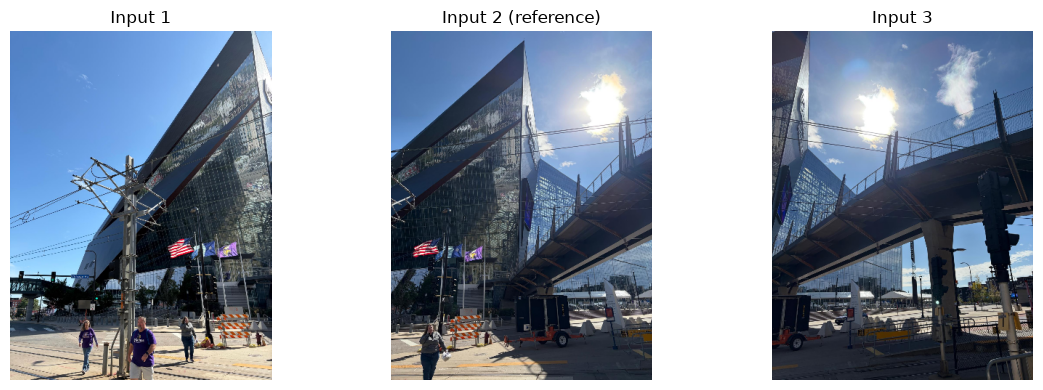

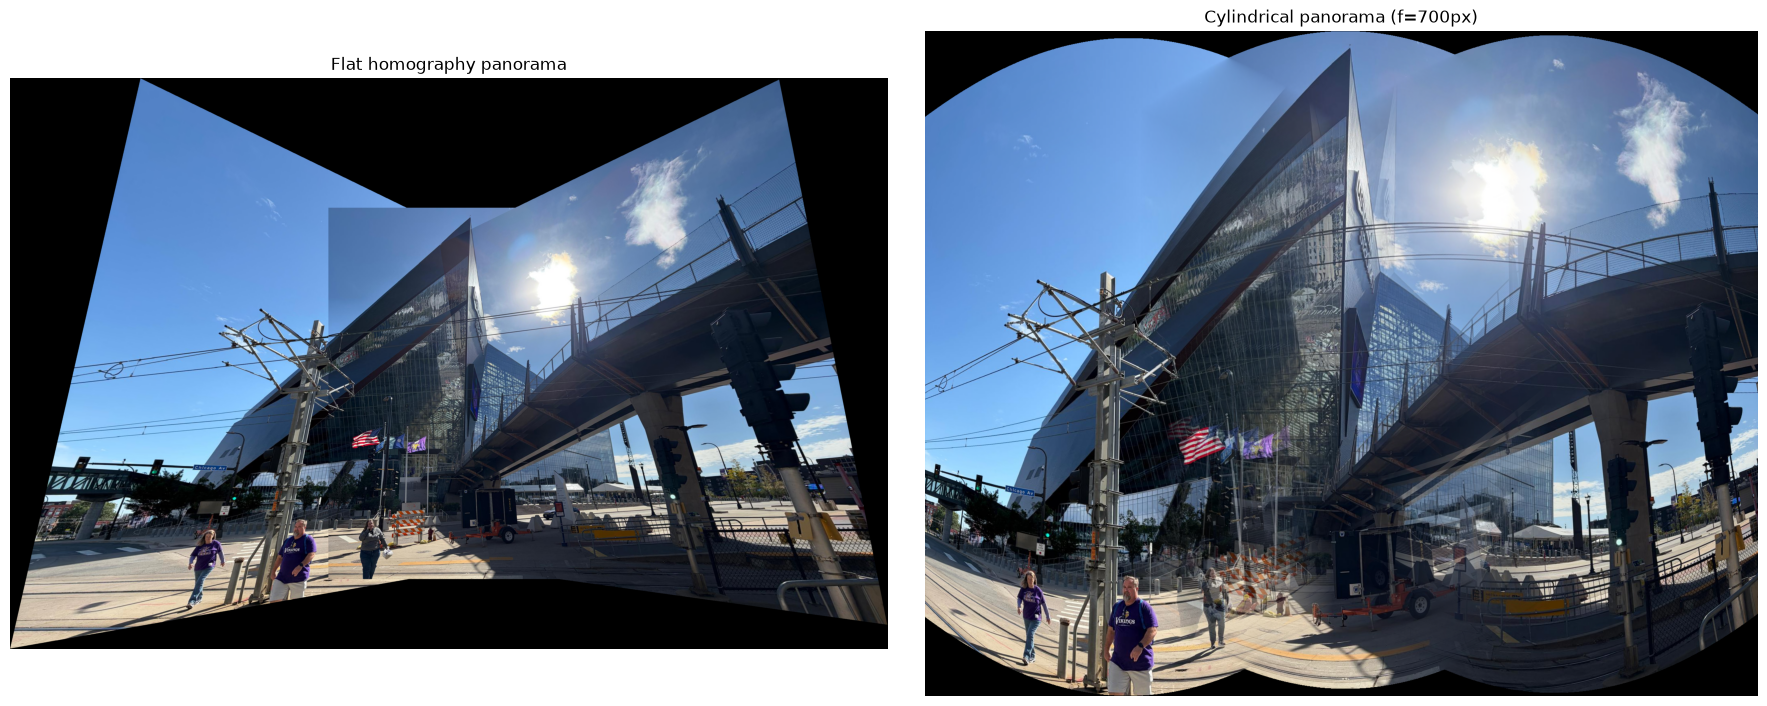

In [40]:
flat_cylindrical_inputs = stitch_flat_with_reference(cylindrical_images, reference_index=1)
save_image(flat_cylindrical_inputs, "outputs/cylindrical_views_flat.jpg")

cylindrical_panorama, cylindrical_views, cylindrical_positions = stitch_cylindrical_images(
    cylindrical_images,
    focal_scale,
)

save_image(flat_cylindrical_inputs, "outputs/cylindrical_views_flat.jpg")
save_image(cylindrical_panorama, "outputs/cylindrical_views_cylindrical.jpg")
print("Cylinder scale:", focal_scale, "px")
print("Flat panorama canvas:", flat_cylindrical_inputs.shape[1], "x", flat_cylindrical_inputs.shape[0])
print("Cylindrical panorama canvas:", cylindrical_panorama.shape[1], "x", cylindrical_panorama.shape[0])
print("Cylindrical image positions:", cylindrical_positions)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, image, title in zip(
    axes,
    cylindrical_images,
    ["Input 1", "Input 2 (reference)", "Input 3"],
):
    thumbnail_width = 360
    thumbnail_height = int(image.shape[0] * thumbnail_width / image.shape[1])
    thumbnail = cv2.resize(image, (thumbnail_width, thumbnail_height))
    axis.imshow(cv2.cvtColor(thumbnail, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for axis, image, title in zip(
    axes,
    [flat_cylindrical_inputs, cylindrical_panorama],
    ["Flat homography panorama", f"Cylindrical panorama (f={focal_scale:.0f}px)"],
):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()
